In [41]:
from PIL import Image
import os
import csv

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [72]:
from models import models as current_models

MODEL_NAME = "mobilenet"
WEIGHTS_DIR = "weights_mobilenet"
CONTINUE_FROM = None#"weights_custom_model/best_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ModelClass = current_models[MODEL_NAME]
model = ModelClass().to(device)
print('using device:', device)

if CONTINUE_FROM:
    # carregar pesos no modelo
    model.load_state_dict(torch.load(CONTINUE_FROM))

def load_model(best=True):
    _from = 'best_model.pth' if best else 'last_model.pth'
    model.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, _from), map_location=device))

load_model()

using device: cpu


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [73]:
norm_image = lambda x: x*2-1.
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(norm_image)
])

mean_scaling = torch.tensor([254.93, 218.01, 12.71, 19.33, 18.10]).to(device)

In [74]:
import captum
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

import os, sys
import json

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

tensor([[519.0463, 416.9734,  30.0969,  34.0655,  38.7151]])


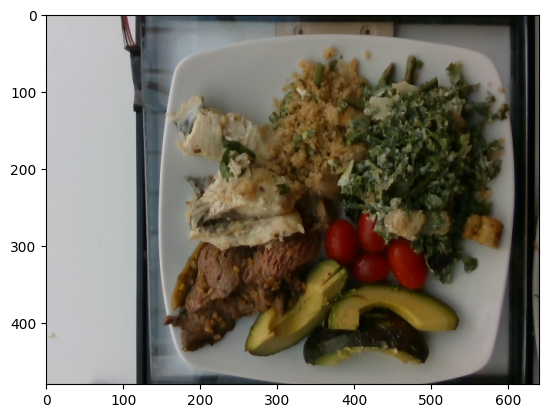

In [83]:
def inference(img_path):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)*mean_scaling
    print(output)
# dish_1558375833,317.032013,92.000000,25.116001,3.864000,17.756001
img_path = "./food_dataset/realsense_overhead/dish_1568315177/rgb.png"
inference(img_path)
# 240.425751,194.000000,10.293161,10.249402,25.324493
test_img = Image.open(img_path)
test_img_data = np.asarray(test_img)
plt.imshow(test_img_data)
plt.show()

In [84]:
input_img = transform_test(test_img)
input_img = input_img.unsqueeze(0)

In [85]:
integrated_gradients = IntegratedGradients(model)

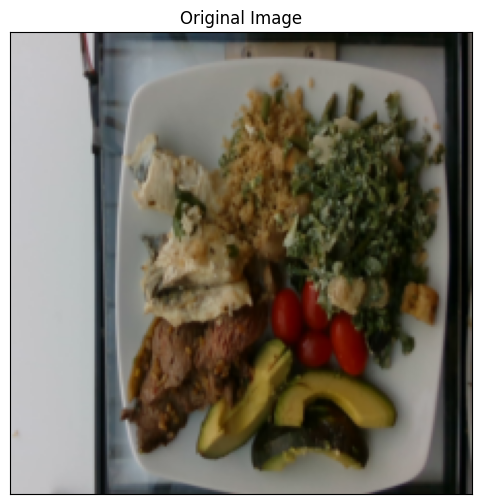

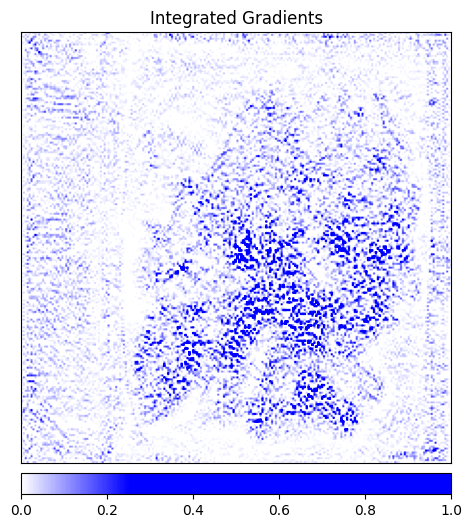

In [87]:
attributions_ig = integrated_gradients.attribute(input_img, target=4, n_steps=50)


_ = viz.visualize_image_attr(None, np.transpose(((input_img+1)/2).squeeze().cpu().detach().numpy(), (1,2,0)),
                      method="original_image", title="Original Image")


default_cmap = LinearSegmentedColormap.from_list('custom blue',
                                                 [(0, '#ffffff'),
                                                  (0.25, '#0000ff'),
                                                  (1, '#0000ff')], N=256)
_ = viz.visualize_image_attr(np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             np.transpose(((input_img+1)/2).squeeze().cpu().detach().numpy(), (1,2,0)),
                             method='heat_map',
                             cmap=default_cmap,
                             show_colorbar=True,
                             sign='positive',
                             title='Integrated Gradients')

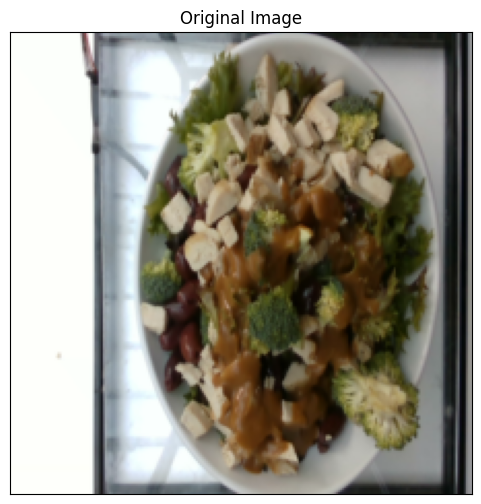

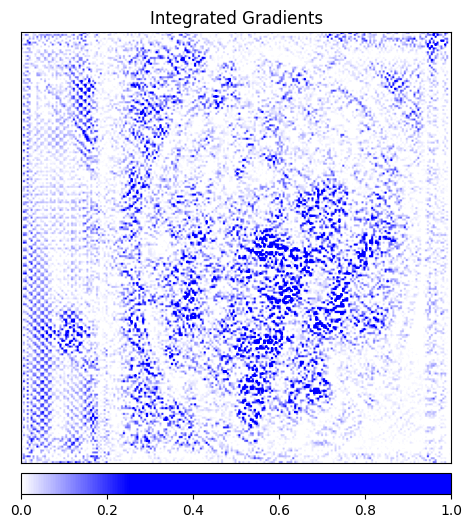

In [79]:
_ = viz.visualize_image_attr(None, np.transpose(((input_img+1)/2).squeeze().cpu().detach().numpy(), (1,2,0)),
                      method="original_image", title="Original Image")


default_cmap = LinearSegmentedColormap.from_list('custom blue',
                                                 [(0, '#ffffff'),
                                                  (0.25, '#0000ff'),
                                                  (1, '#0000ff')], N=256)
_ = viz.visualize_image_attr(np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             np.transpose(((input_img+1)/2).squeeze().cpu().detach().numpy(), (1,2,0)),
                             method='heat_map',
                             cmap=default_cmap,
                             show_colorbar=True,
                             sign='positive',
                             title='Integrated Gradients')